# YOLO11 axmodel 推論例

このノートブックでは、YOLO11のaxmodelを使用した推論の方法を示します。前処理、モデル推論、後処理（分布焦点損失（DFL）のデコードを含む）、および結果の可視化のステップが含まれます。

## 1. 必要なライブラリのインストール

以下のPythonライブラリがインストールされていることを確認してください。まだインストールされていない場合は、次のコードブロックのコメントを解除して実行できます。


In [1]:
!pip install numpy opencv-python matplotlib

## 2. ライブラリのインポートとパラメータの設定

モデルのパス、入力画像のパス、信頼度の閾値、非最大抑制の閾値、入力サイズ、クラス名など、必要なパラメータを設定します。


In [2]:
import axengine as axe
from axengine import axclrt_provider_name, axengine_provider_name
import numpy as np
import cv2
import matplotlib.pyplot as plt
from dataclasses import dataclass

# 設定パラメータ
MODEL_PATH = 'yolo11n.axmodel'          # あなたのYOLOv8 ONNXモデルのパスに置き換えてください
IMAGE_PATH = 'dog.jpg'                  # 検出したい画像のパスに置き換えてください
CONFIDENCE_THRESHOLD = 0.45             # 信頼度の閾値
NMS_THRESHOLD = 0.45                   # 非最大抑制の閾値
INPUT_SIZE = (320, 320)                 # 入力サイズ
REG_MAX = 16                            # DFLの最大分布

# COCOクラス名（必要に応じて完全なリストを追加してください）
COCO_CLASSES = [
    'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant',
    'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog',
    'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra',
    'giraffe', 'backpack', 'umbrella', 'handbag', 'tie',
    'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball',
    'kite', 'baseball bat', 'baseball glove', 'skateboard',
    'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup',
    'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple',
    'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza',
    'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed',
    'dining table', 'toilet', 'tv', 'laptop', 'mouse', 'remote',
    'keyboard', 'cell phone', 'microwave', 'oven', 'toaster',
    'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors',
    'teddy bear', 'hair drier', 'toothbrush'
]

[INFO] Available providers:  ['AxEngineExecutionProvider']


## 3. 補助的なデータ構造と関数の定義

検出されたオブジェクトを格納するためのデータクラスObjectと、補助関数sigmoid、softmax、decode_distributionsを定義します。

In [3]:
@dataclass
class Object:
    bbox: list  # [x0, y0, width, height]
    label: int
    prob: float

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def softmax(x, axis=-1):
    """
    安定したSoftmaxの実装
    """
    x = x - np.max(x, axis=axis, keepdims=True)  # 数値の安定性
    e_x = np.exp(x)
    return e_x / np.sum(e_x, axis=axis, keepdims=True)

def decode_distributions(feat, reg_max=16):
    """
    分布焦点損失（DFL）の出力をデコードする
    feat: 形状 [num_bboxes, 4, reg_max] の配列
    戻り値: 解読された距離 [num_bboxes, 4]
    """
    # Softmaxを適用
    prob = softmax(feat, axis=-1)  # [num_bboxes, 4, reg_max]
    # 期待値を計算
    dis = np.sum(prob * np.arange(reg_max), axis=-1)  # [num_bboxes, 4]
    return dis

## 4. 前処理関数の定義

入力画像を読み込み、色空間の変換、リサイズ、正規化、形状の変換を行い、最終的にモデルが必要とする入力テンソルを生成します。

In [4]:
def preprocess(image_path, input_size):
    """
    入力画像を読み込み、前処理を行います
    """
    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"画像ファイルを読み取れませんでした: {image_path}")
    original_shape = image.shape[:2]  # (高さ, 幅)
    # 色空間変換 BGRからRGBへ
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    # モデルの入力サイズにリサイズ
    resized_image = cv2.resize(image, input_size)
    # uint8型のまま保持し、正規化は行いません
    input_tensor = np.expand_dims(resized_image, axis=0).astype(np.uint8)  # [1, 320, 320, 3]
    return input_tensor, original_shape, image

## 5. 後処理関数の定義

モデルの出力を処理し、検出結果に解析します。これには、バウンディングボックスのデコード（DFLを使用）、信頼度フィルタリング、および非最大抑制（NMS）が含まれます。


In [5]:
def postprocess(outputs, original_shape, input_size, confidence_threshold, nms_threshold, reg_max=16):
    """
    モデルの出力を処理して、検出結果に解析します。
    """
    # 出力ヘッド、入力サイズに基づいてgrid_sizeを調整
    heads = [
        {'output': outputs[0], 'grid_size': input_size[0] // 8, 'stride': 8},
        {'output': outputs[1], 'grid_size': input_size[0] // 16, 'stride': 16},
        {'output': outputs[2], 'grid_size': input_size[0] // 32, 'stride': 32}
    ]

    detections = []
    num_classes = 80  # COCOのクラス数
    bbox_channels = 4 * reg_max  # 最初の64チャンネルはbbox関連
    class_channels = num_classes  # 最後の80チャンネルはクラススコア

    for head in heads:
        output = head['output']  # [1, grid_h, grid_w, 144]
        batch_size, grid_h, grid_w, channels = output.shape
        stride = head['stride']

        print(f"stride {stride}、grid_size {grid_h}x{grid_w}、出力形状 {output.shape} を処理中")

        if batch_size != 1:
            raise ValueError("現在、このコードはbatch_size=1のみに対応しています")

        # bboxとclass部分を分割
        bbox_part = output[:, :, :, :bbox_channels]  # [1, 40, 40, 64]
        class_part = output[:, :, :, bbox_channels:]  # [1, 40, 40, 80]

        print(f"bbox_partの形状: {bbox_part.shape}、class_partの形状: {class_part.shape}")

        # bbox_partを処理
        num_bbox_params = 4  # 左、上、右、下
        if bbox_channels != num_bbox_params * reg_max:
            raise ValueError(f"bbox_channels ({bbox_channels}) は4*reg_max ({4 * reg_max}) と一致しません")

        # bbox_partを [1, grid_h, grid_w, 4, 16] に再形成
        try:
            bbox_part = bbox_part.reshape(batch_size, grid_h, grid_w, num_bbox_params, reg_max)
        except ValueError as e:
            print(f"bbox_partの再形成に失敗しました: {e}")
            print(f"現在のbbox_partの形状: {bbox_part.shape}、期待される要素数: {batch_size * grid_h * grid_w * num_bbox_params * reg_max}")
            raise

        # [grid_h * grid_w, 4, 16] に再形成
        bbox_part = bbox_part.reshape(grid_h * grid_w, num_bbox_params, reg_max)  # [1600, 4, 16]

        # class_partを処理
        class_part = class_part.reshape(batch_size, grid_h * grid_w, class_channels)  # [1, 1600, 80]

        print(f"再形成後のbbox_partの形状: {bbox_part.shape}、class_partの形状: {class_part.shape}")

        # グリッドセルを繰り返し処理
        for b in range(batch_size):
            for i in range(grid_h * grid_w):
                h = i // grid_w
                w = i % grid_w
                # クラススコアを取得
                class_scores = class_part[b, i, :]  # [80]
                class_id = np.argmax(class_scores)
                class_score = class_scores[class_id]
                box_prob = sigmoid(class_score)

                if box_prob < confidence_threshold:
                    continue

                # bboxパラメータを取得
                bbox = bbox_part[i, :, :]  # [4, 16]

                # bboxパラメータをデコード
                dis_left = decode_distributions(bbox[0, :], reg_max)
                dis_top = decode_distributions(bbox[1, :], reg_max)
                dis_right = decode_distributions(bbox[2, :], reg_max)
                dis_bottom = decode_distributions(bbox[3, :], reg_max)

                # 中心座標を計算
                pb_cx = (w + 0.5) * stride
                pb_cy = (h + 0.5) * stride

                # バウンディングボックス座標を計算
                x0 = pb_cx - dis_left * stride
                y0 = pb_cy - dis_top * stride
                x1 = pb_cx + dis_right * stride
                y1 = pb_cy + dis_bottom * stride

                # bboxを元の画像サイズにリスケール
                scale_x = original_shape[1] / input_size[0]
                scale_y = original_shape[0] / input_size[1]
                x0 = np.clip(x0 * scale_x, 0, original_shape[1] - 1)
                y0 = np.clip(y0 * scale_y, 0, original_shape[0] - 1)
                x1 = np.clip(x1 * scale_x, 0, original_shape[1] - 1)
                y1 = np.clip(y1 * scale_y, 0, original_shape[0] - 1)

                # 幅と高さを計算
                width = x1 - x0
                height = y1 - y0

                # 検出結果に追加
                detections.append(Object(
                    bbox=[float(x0), float(y0), float(width), float(height)],
                    label=int(class_id),
                    prob=float(box_prob)
                ))

    # 非最大抑制 (NMS) を適用
    if len(detections) == 0:
        return []

    boxes = np.array([d.bbox for d in detections])  # [num_detections, 4]
    scores = np.array([d.prob for d in detections])  # [num_detections]
    class_ids = np.array([d.label for d in detections])  # [num_detections]

    final_detections = []

    unique_classes = np.unique(class_ids)
    for cls in unique_classes:
        idxs = np.where(class_ids == cls)[0]
        cls_boxes = boxes[idxs]
        cls_scores = scores[idxs]

        # NMSを計算
        x1_cls = cls_boxes[:, 0]
        y1_cls = cls_boxes[:, 1]
        x2_cls = cls_boxes[:, 0] + cls_boxes[:, 2]
        y2_cls = cls_boxes[:, 1] + cls_boxes[:, 3]

        areas = (x2_cls - x1_cls) * (y2_cls - y1_cls)
        order = cls_scores.argsort()[::-1]

        keep = []
        while order.size > 0:
            i = order[0]
            keep.append(i)

            if order.size == 1:
                break

            xx1 = np.maximum(x1_cls[i], x1_cls[order[1:]])
            yy1 = np.maximum(y1_cls[i], y1_cls[order[1:]])
            xx2 = np.minimum(x2_cls[i], x2_cls[order[1:]])
            yy2 = np.minimum(y2_cls[i], y2_cls[order[1:]])

            w = np.maximum(0, xx2 - xx1)
            h = np.maximum(0, yy2 - yy1)
            intersection = w * h
            iou = intersection / (areas[i] + areas[order[1:]] - intersection)

            inds = np.where(iou <= nms_threshold)[0]
            order = order[inds + 1]

        for idx in keep:
            final_detections.append(Object(
                bbox=cls_boxes[idx].tolist(),
                label=int(cls),
                prob=float(cls_scores[idx])
            ))

    return final_detections

## 6. 推論と可視化のための主関数を定義する

入力画像の前処理、モデルの読み込み、推論の実行、出力の後処理を行い、画像に検出結果を描画する。

In [6]:
def main():
    # 前処理
    try:
        input_tensor, original_shape, original_image = preprocess(IMAGE_PATH, INPUT_SIZE)
    except FileNotFoundError as e:
        print(e)
        return

    # ONNXモデルの読み込み
    try:
        session = axe.InferenceSession(MODEL_PATH)
    except Exception as e:
        print(f"モデルの読み込み中にエラーが発生しました: {e}")
        return

    # モデルの入力名を取得
    input_name = session.get_inputs()[0].name

    # モデルの出力を取得
    output_names = [output.name for output in session.get_outputs()]

    # 推論
    try:
        outputs = session.run(output_names, {input_name: input_tensor})
    except Exception as e:
        print(f"推論中にエラーが発生しました: {e}")
        return

    # 後処理
    try:
        detections = postprocess(
            outputs,
            original_shape,
            INPUT_SIZE,
            CONFIDENCE_THRESHOLD,
            NMS_THRESHOLD,
            reg_max=REG_MAX
        )
    except Exception as e:
        print(f"後処理中にエラーが発生しました: {e}")
        return

    # 結果を可視化
    for det in detections:
        bbox = det.bbox
        score = det.prob
        class_id = det.label
        if class_id >= len(COCO_CLASSES):
            label = f"cls{class_id}: {score:.2f}"
        else:
            label = f"{COCO_CLASSES[class_id]}: {score:.2f}"
        x, y, w, h = map(int, bbox)
        cv2.rectangle(original_image, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.putText(original_image, label, (x, y - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    # 結果を表示
    plt.figure(figsize=(12, 8))
    plt.imshow(original_image)
    plt.axis('off')
    plt.title('検出結果')
    plt.show()

## 7. メイン関数の実行

推論を行い、検出結果を可視化するためにメイン関数を実行します。

[INFO] Using provider: AxEngineExecutionProvider
[INFO] Chip type: ChipType.MC20E
[INFO] VNPU type: VNPUType.DISABLED
[INFO] Engine version: 2.6.3sp
[INFO] Model type: 1 (full core)
[INFO] Compiler version: 3.2-patch1 93dc9c99
Processing head with stride 8, grid_size 40x40, output shape (1, 40, 40, 144)
bbox_part shape: (1, 40, 40, 64), class_part shape: (1, 40, 40, 80)
After reshaping, bbox_part shape: (1600, 4, 16), class_part shape: (1, 1600, 80)
Processing head with stride 16, grid_size 20x20, output shape (1, 20, 20, 144)
bbox_part shape: (1, 20, 20, 64), class_part shape: (1, 20, 20, 80)
After reshaping, bbox_part shape: (400, 4, 16), class_part shape: (1, 400, 80)
Processing head with stride 32, grid_size 10x10, output shape (1, 10, 10, 144)
bbox_part shape: (1, 10, 10, 64), class_part shape: (1, 10, 10, 80)
After reshaping, bbox_part shape: (100, 4, 16), class_part shape: (1, 100, 80)


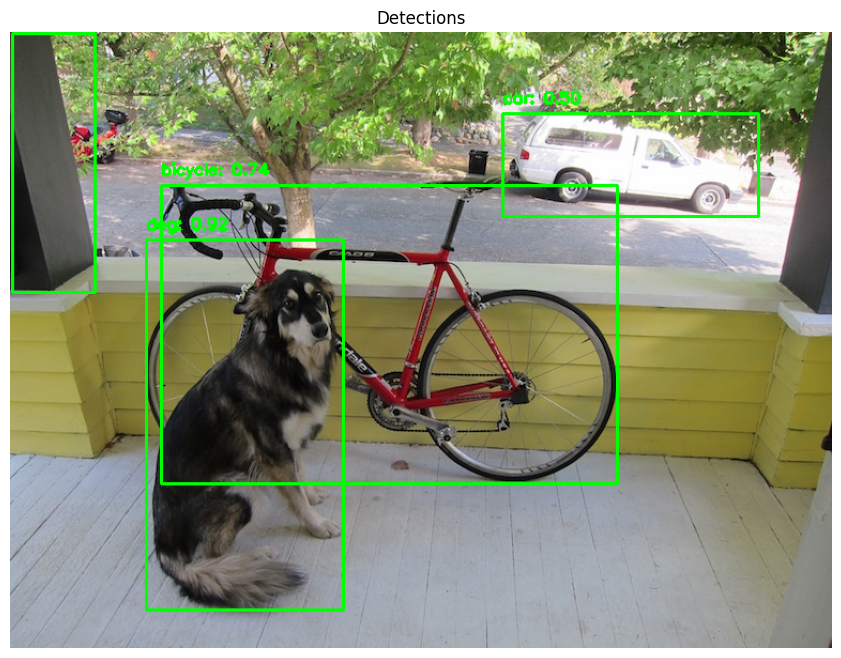

In [7]:
if __name__ == '__main__':
    main()